# 🧠 Stroke Prediction – Complete ML Pipeline
### Data Mining Project | New Mansoura University | AIE 323
---
**Domain:** Healthcare  
**Problem:** Binary classification – will a patient have a stroke? (0 = No, 1 = Yes)  
**Data Source:** Gold Layer – Data Warehouse (SQL Server / Medallion Architecture)

| Step | Description |
|------|-------------|
| 1 | Imports & Setup |
| 2 | Data Loading from DWH |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Preprocessing & Feature Engineering |
| 5 | Model Training (LR · RF · XGBoost) |
| 6 | Evaluation (Accuracy · F1 · ROC-AUC · Confusion Matrix) |
| 7 | Feature Importance |
| 8 | Final Recommendation |


## 📦 Step 1 – Imports & Setup

In [37]:
# ── Standard Libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Database ─────────────────────────────────────────────────
from sqlalchemy import create_engine

# ── Sklearn ──────────────────────────────────────────────────
from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics           import (accuracy_score, precision_score, recall_score,
                                        f1_score, roc_auc_score, confusion_matrix,
                                        classification_report, roc_curve)

# ── XGBoost ──────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠  XGBoost not found – using GradientBoosting instead")

# ── Plot Style ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor'  : '#1a1d27',
    'axes.edgecolor'  : '#3a3f55',
    'axes.labelcolor' : '#e0e0e0',
    'xtick.color'     : '#b0b0b0',
    'ytick.color'     : '#b0b0b0',
    'text.color'      : '#e0e0e0',
    'grid.color'      : '#2a2d3a',
    'grid.alpha'      : 0.5,
})

PALETTE = ['#6c63ff', '#ff6584', '#43e97b', '#f9ca24', '#00d2ff']
print("✅ All imports loaded successfully")



✅ XGBoost available
✅ All imports loaded successfully


## 🗄️ Step 2 – Data Loading from Data Warehouse
Load data directly from the **Gold Layer** of the SQL Server Data Warehouse.  
Falls back to synthetic demo data if the connection is unavailable.


In [38]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np

# ── Connection Config ────────────────────────────────────────
SERVER   = 'LAPTOP-0ET1RSM5'    # عدّله لو مختلف عندك
DATABASE = 'StrokePrediction'

# ── FIXED QUERY (MATCHES YOUR GOLD LAYER) ────────────────────
QUERY = """
SELECT
    f.patient_id,
    f.age,
    f.hypertension,
    f.heart_disease,

    f.avg_glucose_level,
    f.bmi,

    f.avg_RestingBP,
    f.heart_cholesterol,
    f.avg_MaxHR,
    f.avg_Oldpeak,
    f.heart_disease_rate,

    f.avg_height,
    f.avg_weight,
    f.avg_ap_hi,
    f.avg_ap_lo,
    f.cardio_cholesterol,
    f.cardio_gluc,
    f.cardio_rate,

    f.stroke_target,

    d.gender,
    d.ever_married,
    d.work_type,
    d.Residence_type,

    l.smoking_status,
    l.smoke_flag,
    l.alco_flag

FROM gold.fact_patient_health f
LEFT JOIN gold.dim_patient_info d 
    ON f.patient_id = d.patient_id
LEFT JOIN gold.dim_lifestyle l 
    ON f.patient_id = l.patient_id
"""

# ── CONNECTION STRING ────────────────────────────────────────
conn_str = (
    f"mssql+pyodbc://{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

# ── LOAD DATA ────────────────────────────────────────────────
try:
    engine = create_engine(conn_str)
    df = pd.read_sql(QUERY, engine)

    print("✅ Connected to SQL Server successfully!")
    print(f"   Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

except Exception as e:
    print(f"⚠ SQL connection failed: {e}")
    print("   ↳ Using synthetic fallback data...\n")

    np.random.seed(42)
    n = 5000

    df = pd.DataFrame({
        'patient_id': range(n),
        'age': np.random.randint(20, 82, n),
        'hypertension': np.random.randint(0, 2, n),
        'heart_disease': np.random.randint(0, 2, n),

        'avg_glucose_level': np.random.normal(106, 45, n),
        'bmi': np.random.normal(28, 6, n),

        'avg_RestingBP': np.random.normal(132, 18, n),
        'heart_cholesterol': np.random.normal(200, 50, n),
        'avg_MaxHR': np.random.normal(150, 25, n),
        'avg_Oldpeak': np.random.uniform(0, 4, n),
        'heart_disease_rate': np.random.uniform(0, 1, n),

        'avg_height': np.random.normal(168, 10, n),
        'avg_weight': np.random.normal(72, 15, n),
        'avg_ap_hi': np.random.normal(120, 20, n),
        'avg_ap_lo': np.random.normal(80, 12, n),
        'cardio_cholesterol': np.random.choice([1, 2, 3], n),
        'cardio_gluc': np.random.choice([1, 2, 3], n),
        'cardio_rate': np.random.uniform(0, 1, n),

        'stroke_target': np.random.choice([0, 1], n, p=[0.95, 0.05]),

        'gender': np.random.choice(['Male', 'Female'], n),
        'ever_married': np.random.choice(['Yes', 'No'], n),
        'work_type': np.random.choice(['Private','Self-employed','Govt_job','children'], n),
        'Residence_type': np.random.choice(['Urban','Rural'], n),

        'smoking_status': np.random.choice(
            ['never smoked','formerly smoked','smokes','Unknown'], n),
        'smoke_flag': np.random.randint(0, 2, n),
        'alco_flag': np.random.randint(0, 2, n),
    })

    print(f"   Synthetic dataset ready: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Connected to SQL Server successfully!
   Loaded: 143,960 rows × 26 columns


In [39]:
# ── Quick Preview ────────────────────────────────────────────
print("Shape:", df.shape)
df.head()


Shape: (143960, 26)


,patient_id,age,hypertension,heart_disease,avg_glucose_level,bmi,avg_RestingBP,heart_cholesterol,avg_MaxHR,avg_Oldpeak,...,cardio_gluc,cardio_rate,stroke_target,gender,ever_married,work_type,Residence_type,smoking_status,smoke_flag,alco_flag
0,55235,50,0,0,85.92,37.3,125.714286,219.285714,140.571429,0.528571,...,1.0,0.0,0,Female,Yes,Self-employed,Urban,smokes,0,0
1,55235,50,0,0,85.92,37.3,125.714286,219.285714,140.571429,0.528571,...,1.0,0.0,0,Female,Yes,Self-employed,Urban,smokes,0,0
2,55235,50,0,0,85.92,37.3,125.714286,219.285714,140.571429,0.528571,...,1.0,0.0,0,Female,Yes,Self-employed,Urban,smokes,0,0
3,55235,50,0,0,85.92,37.3,125.714286,219.285714,140.571429,0.528571,...,1.0,0.0,0,Female,Yes,Self-employed,Urban,smokes,0,0
4,55235,50,0,0,85.92,37.3,125.714286,219.285714,140.571429,0.528571,...,1.0,0.0,0,Female,Yes,Self-employed,Urban,smokes,0,0


In [40]:
# ── Basic Info ───────────────────────────────────────────────
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143960 entries, 0 to 143959
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   patient_id          143960 non-null  int64  
 1   age                 143960 non-null  object 
 2   hypertension        143960 non-null  int64  
 3   heart_disease       143960 non-null  int64  
 4   avg_glucose_level   143960 non-null  float64
 5   bmi                 143960 non-null  float64
 6   avg_RestingBP       127608 non-null  float64
 7   heart_cholesterol   127608 non-null  float64
 8   avg_MaxHR           127608 non-null  float64
 9   avg_Oldpeak         127608 non-null  float64
 10  heart_disease_rate  127608 non-null  float64
 11  avg_height          112288 non-null  float64
 12  avg_weight          112288 non-null  float64
 13  avg_ap_hi           112288 non-null  float64
 14  avg_ap_lo           112288 non-null  float64
 15  cardio_cholesterol  112288 non-nul

In [41]:
# ── Descriptive Statistics ───────────────────────────────────
df.describe().round(2)


,patient_id,hypertension,heart_disease,avg_glucose_level,bmi,avg_RestingBP,heart_cholesterol,avg_MaxHR,avg_Oldpeak,heart_disease_rate,avg_height,avg_weight,avg_ap_hi,avg_ap_lo,cardio_cholesterol,cardio_gluc,cardio_rate,stroke_target,smoke_flag,alco_flag
count,143960.00,143960.00,143960.00,143960.00,143960.00,127608.00,127608.00,127608.00,127608.00,127608.00,112288.00,112288.00,112288.00,112288.00,112288.00,112288.00,112288.00,143960.00,143960.00,143960.00
mean,36778.98,0.13,0.05,110.65,29.49,132.25,218.48,139.99,0.83,0.46,165.46,73.12,126.62,96.75,1.05,1.05,0.02,0.05,0.08,0.05
std,21224.59,0.34,0.23,48.79,9.75,7.97,45.38,11.11,0.46,0.28,5.39,7.26,8.93,50.45,0.25,0.26,0.14,0.21,0.28,0.23
min,67.00,0.00,0.00,55.12,0.00,100.00,0.00,110.67,0.00,0.00,154.00,60.00,110.00,40.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,18181.00,0.00,0.00,78.18,25.40,128.75,197.65,132.70,0.37,0.20,161.00,68.31,120.00,77.00,1.00,1.00,0.00,0.00,0.00,0.00
50%,37440.00,0.00,0.00,93.96,29.60,132.24,216.60,140.57,0.88,0.56,163.00,71.62,123.00,80.00,1.00,1.00,0.00,0.00,0.00,0.00
75%,55244.00,0.00,0.00,121.11,34.60,135.37,243.17,147.20,1.04,0.69,170.00,75.71,130.00,86.00,1.00,1.00,0.00,0.00,0.00,0.00
max,72940.00,1.00,1.00,271.74,97.60,170.00,392.00,191.00,3.50,1.00,176.00,93.00,150.00,386.00,3.00,3.00,1.00,1.00,1.00,1.00


## 📊 Step 3 – Exploratory Data Analysis (EDA)
Understanding the data before modelling is critical in healthcare projects.


Target Distribution:
  No Stroke (0): 137,272  (95.4%)
  Stroke    (1): 6,688  (4.6%)

⚠ Dataset is imbalanced → class_weight='balanced' will be used in models


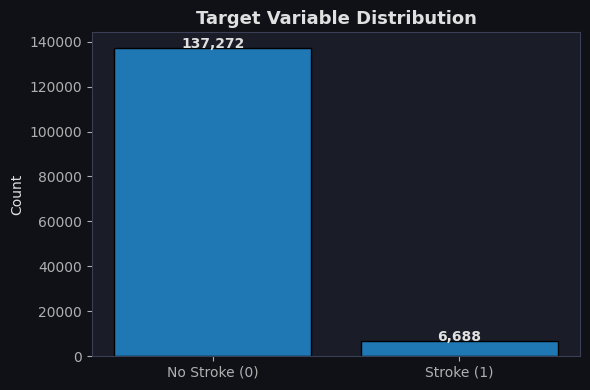

In [42]:
%matplotlib inline
import matplotlib.pyplot as plt

# ── 3.1 Target Distribution ──────────────────────────────────

# استخدم الاسم الصحيح من Gold layer
target_col = 'stroke_target'

# تأكد إن العمود موجود
if target_col not in df.columns:
    raise ValueError(f"Column '{target_col}' not found in dataframe. Available columns: {df.columns}")

# حساب التوزيع
stroke_counts = df[target_col].value_counts()
stroke_pct = df[target_col].value_counts(normalize=True) * 100

print("Target Distribution:")
print(f"  No Stroke (0): {stroke_counts.get(0, 0):,}  ({stroke_pct.get(0, 0):.1f}%)")
print(f"  Stroke    (1): {stroke_counts.get(1, 0):,}  ({stroke_pct.get(1, 0):.1f}%)")
print("\n⚠ Dataset is imbalanced → class_weight='balanced' will be used in models")

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ['No Stroke (0)', 'Stroke (1)'],
    [stroke_counts.get(0, 0), stroke_counts.get(1, 0)],
    edgecolor='black'
)

for i, val in enumerate([stroke_counts.get(0, 0), stroke_counts.get(1, 0)]):
    ax.text(i, val + 30, f'{val:,}', ha='center', fontweight='bold')

ax.set_title('Target Variable Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()
plt.close()


Missing Values:
            Column  Count  Percent
         avg_ap_hi  31672    22.00
        avg_height  31672    22.00
       cardio_gluc  31672    22.00
cardio_cholesterol  31672    22.00
         avg_ap_lo  31672    22.00
        avg_weight  31672    22.00
       cardio_rate  31672    22.00
 heart_cholesterol  16352    11.36
         avg_MaxHR  16352    11.36
heart_disease_rate  16352    11.36
     avg_RestingBP  16352    11.36
       avg_Oldpeak  16352    11.36
            gender      8     0.01


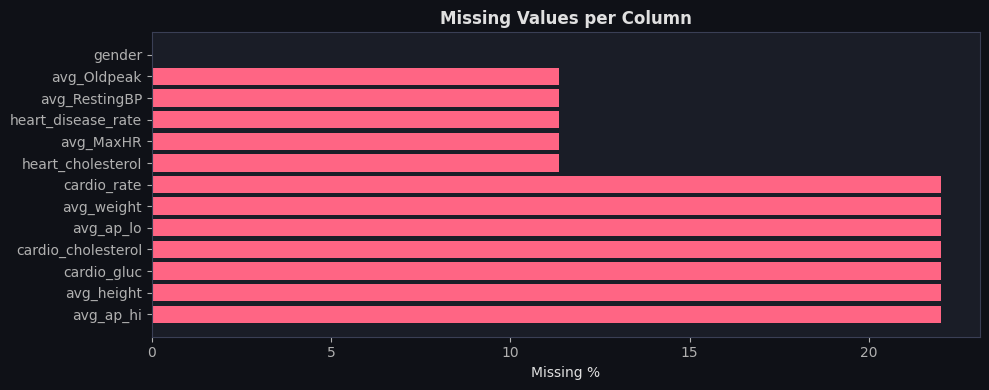

In [43]:
# ── 3.2 Missing Values ───────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print("✅ No missing values found in the dataset.")
else:
    print("Missing Values:")
    miss_df = pd.DataFrame({
        'Column' : missing.index,
        'Count'  : missing.values,
        'Percent': (missing.values / len(df) * 100).round(2)
    })
    print(miss_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing.index, missing.values / len(df) * 100, color=PALETTE[1])
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values per Column', fontweight='bold')
    plt.tight_layout()
    plt.show()
plt.close()


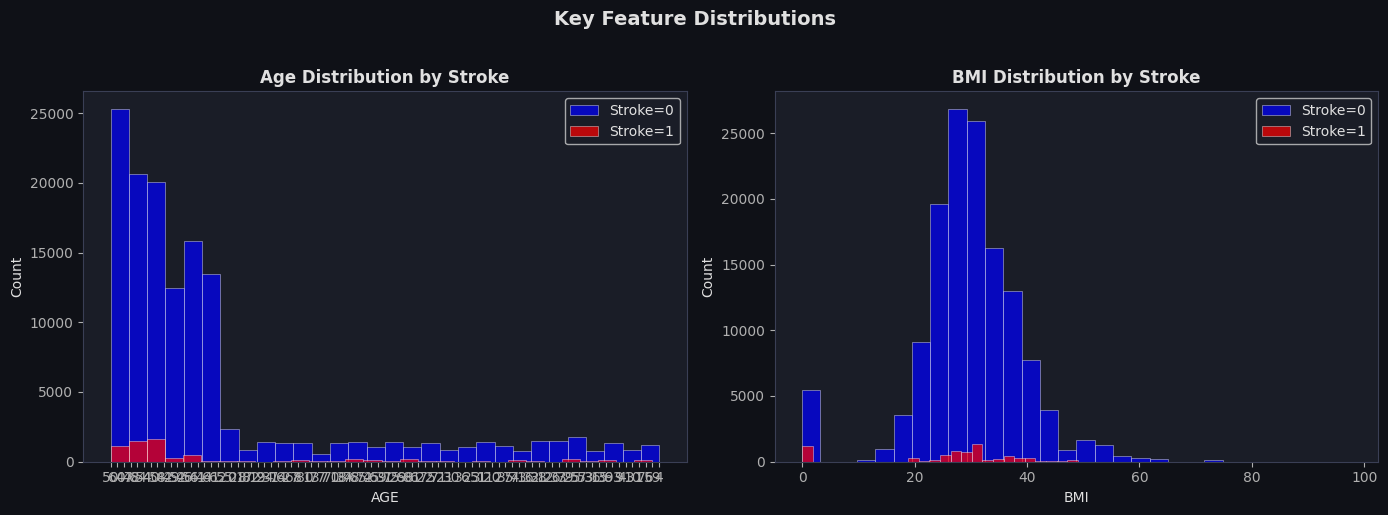

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt

# ── 3.3 Age & BMI Distributions by Stroke ────────────────────

target_col = 'stroke_target'

# تأكد إن العمود موجود
if target_col not in df.columns:
    raise ValueError(f"Column '{target_col}' not found. Available: {df.columns}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['age', 'bmi'],
    ['Age Distribution by Stroke', 'BMI Distribution by Stroke']
):
    for label, color in zip([0, 1], ['blue', 'red']):

        subset = df[df[target_col] == label][col].dropna()

        ax.hist(
            subset,
            bins=30,
            alpha=0.7,
            color=color,
            label=f'Stroke={label}',
            edgecolor='white',
            linewidth=0.4
        )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col.upper())
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close()

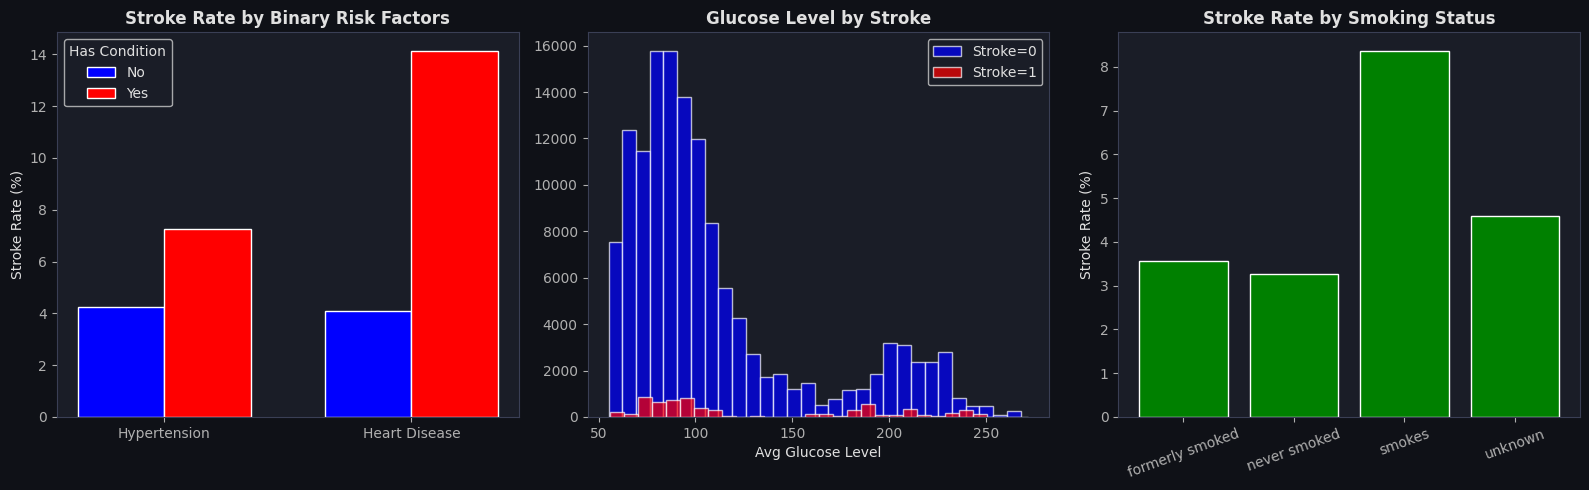

In [45]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# ── 3.4 Stroke Rate by Risk Factors ──────────────────────────

target_col = 'stroke_target'

# تأكد إن العمود موجود
if target_col not in df.columns:
    raise ValueError(f"Column '{target_col}' not found. Available: {df.columns}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# =========================
# 1) Hypertension & Heart Disease
# =========================
ax = axes[0]

risk_features = ['hypertension', 'heart_disease']

rates_no = [
    df[df[f] == 0][target_col].mean() * 100 for f in risk_features
]
rates_yes = [
    df[df[f] == 1][target_col].mean() * 100 for f in risk_features
]

x = np.arange(len(risk_features))
w = 0.35

ax.bar(x - w/2, rates_no,  w, label='No',  color='blue', edgecolor='white')
ax.bar(x + w/2, rates_yes, w, label='Yes', color='red', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['Hypertension', 'Heart Disease'])
ax.set_ylabel('Stroke Rate (%)')
ax.set_title('Stroke Rate by Binary Risk Factors', fontweight='bold')
ax.legend(title='Has Condition')

# =========================
# 2) Avg Glucose
# =========================
ax = axes[1]

for label, color in zip([0, 1], ['blue', 'red']):
    subset = df[df[target_col] == label]['avg_glucose_level'].dropna()
    ax.hist(subset, bins=30, alpha=0.7, color=color,
            label=f'Stroke={label}', edgecolor='white')

ax.set_title('Glucose Level by Stroke', fontweight='bold')
ax.set_xlabel('Avg Glucose Level')
ax.legend()

# =========================
# 3) Smoking Status
# =========================
ax = axes[2]

if 'smoking_status' in df.columns:
    smoke_stroke = df.groupby('smoking_status')[target_col].mean() * 100
    ax.bar(smoke_stroke.index, smoke_stroke.values,
           color='green', edgecolor='white')
    ax.set_title('Stroke Rate by Smoking Status', fontweight='bold')
    ax.set_ylabel('Stroke Rate (%)')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
plt.close()

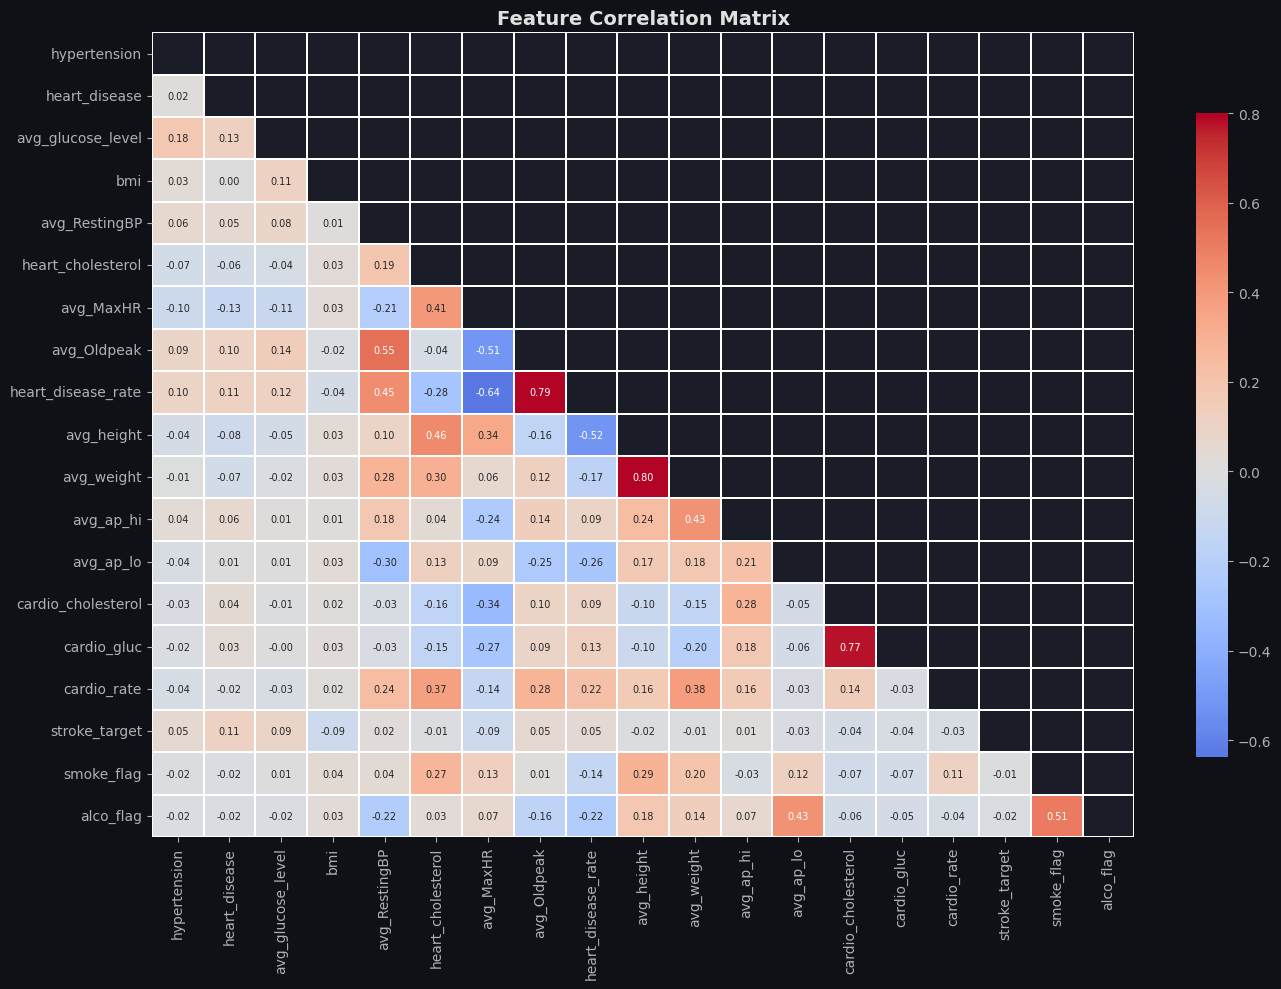

In [46]:
# ── 3.5 Correlation Heatmap ──────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['patient_id']]

fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()
plt.close()


## 🔧 Step 4 – Preprocessing & Feature Engineering
Steps:
- Drop non-feature columns (`patient_id`, `cardio`)
- Encode categorical variables using `LabelEncoder`
- Impute missing values using **median** (robust for medical data)
- Train/Test split with **stratification** (to preserve class ratio)
- Scale features using `StandardScaler` (for Logistic Regression)


In [47]:
# ── 4.1 Drop Irrelevant Columns ──────────────────────────────
df_ml = df.copy()
drop_cols = ['patient_id', 'cardio']   # cardio = separate target, not stroke
df_ml.drop(columns=[c for c in drop_cols if c in df_ml.columns], inplace=True)
print(f"Remaining columns: {df_ml.shape[1]}")


Remaining columns: 25


In [48]:
# ── 4.2 Encode Categorical Variables ─────────────────────────
cat_cols = ['gender', 'ever_married', 'residence_type', 'work_type', 'smoking_status']
cat_cols = [c for c in cat_cols if c in df_ml.columns]

le_map = {}
for col in cat_cols:
    df_ml[col] = df_ml[col].fillna('Unknown')
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_map[col] = le
    print(f"  ✅ Encoded '{col}': {list(le.classes_)}")


  ✅ Encoded 'gender': ['Female', 'Male', 'Unknown']
  ✅ Encoded 'ever_married': ['No', 'Yes']
  ✅ Encoded 'work_type': ['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children']
  ✅ Encoded 'smoking_status': ['formerly smoked', 'never smoked', 'smokes', 'unknown']


In [49]:
# ── 4.3 Smart Missing Value Imputation ───────────────────────
# Using MEDIAN — robust to outliers in medical data (not zero fill!)
num_cols = df_ml.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'stroke']

imputed = []
for col in num_cols:
    miss = df_ml[col].isnull().sum()
    if miss > 0:
        median_val = df_ml[col].median()
        df_ml[col].fillna(median_val, inplace=True)
        imputed.append((col, miss, median_val))

if imputed:
    print("Imputed columns:")
    for col, cnt, med in imputed:
        print(f"  {col:<25}: {cnt} missing → filled with median={med:.2f}")
else:
    print("✅ No imputation needed.")


Imputed columns:
  avg_RestingBP            : 16352 missing → filled with median=132.24
  heart_cholesterol        : 16352 missing → filled with median=216.60
  avg_MaxHR                : 16352 missing → filled with median=140.57
  avg_Oldpeak              : 16352 missing → filled with median=0.88
  heart_disease_rate       : 16352 missing → filled with median=0.56
  avg_height               : 31672 missing → filled with median=163.00
  avg_weight               : 31672 missing → filled with median=71.62
  avg_ap_hi                : 31672 missing → filled with median=123.00
  avg_ap_lo                : 31672 missing → filled with median=80.00
  cardio_cholesterol       : 31672 missing → filled with median=1.00
  cardio_gluc              : 31672 missing → filled with median=1.00
  cardio_rate              : 31672 missing → filled with median=0.00


In [50]:
# ── 4.4 Define Features & Target ─────────────────────────────

TARGET = 'stroke_target'

# تأكد إن العمود موجود
if TARGET not in df_ml.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Available columns: {df_ml.columns}")

X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]

print(f"Features  : {X.shape[1]}")
print(f"Samples   : {X.shape[0]:,}")
print(f"Target    : {dict(y.value_counts())}")

print(f"\nFeature list:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:02d}. {col}")

Features  : 24
Samples   : 143,960
Target    : {0: 137272, 1: 6688}

Feature list:
  01. age
  02. hypertension
  03. heart_disease
  04. avg_glucose_level
  05. bmi
  06. avg_RestingBP
  07. heart_cholesterol
  08. avg_MaxHR
  09. avg_Oldpeak
  10. heart_disease_rate
  11. avg_height
  12. avg_weight
  13. avg_ap_hi
  14. avg_ap_lo
  15. cardio_cholesterol
  16. cardio_gluc
  17. cardio_rate
  18. gender
  19. ever_married
  20. work_type
  21. Residence_type
  22. smoking_status
  23. smoke_flag
  24. alco_flag


In [51]:
# ── 4.5 Train / Test Split (Stratified) ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} samples")
print(f"Test  : {X_test.shape[0]:,} samples")
print(f"\nTrain stroke rate : {y_train.mean()*100:.2f}%")
print(f"Test  stroke rate : {y_test.mean()*100:.2f}%")


Train : 115,168 samples
Test  : 28,792 samples

Train stroke rate : 4.65%
Test  stroke rate : 4.65%


In [52]:
from sklearn.preprocessing import StandardScaler

# ── 1) Separate categorical & numeric columns ───────────────
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

# ── 2) One-hot encode categorical columns ───────────────────
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# ── 3) Align train & test (important fix) ───────────────────
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

# ── 4) Apply scaling ONLY on numeric values ────────────────
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_encoded)
X_test_sc  = scaler.transform(X_test_encoded)

print("✅ Scaling completed successfully!")
print(f"Shape: {X_train_sc.shape}")

Categorical columns: ['age', 'Residence_type']
Numeric columns: ['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'avg_RestingBP', 'heart_cholesterol', 'avg_MaxHR', 'avg_Oldpeak', 'heart_disease_rate', 'avg_height', 'avg_weight', 'avg_ap_hi', 'avg_ap_lo', 'cardio_cholesterol', 'cardio_gluc', 'cardio_rate', 'gender', 'ever_married', 'work_type', 'smoking_status', 'smoke_flag', 'alco_flag']
✅ Scaling completed successfully!
Shape: (115168, 105)


## 🤖 Step 5 – Model Training
Three models are trained:

| Model | Why? |
|-------|------|
| **Logistic Regression** | Baseline, highly interpretable, good for imbalanced data |
| **Random Forest** | Ensemble, handles non-linearity, robust to outliers |
| **XGBoost** | State-of-the-art gradient boosting, best for structured data |

`class_weight='balanced'` is used to handle class imbalance without oversampling.


In [53]:
# ── 5.1 Define Models ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
}

if XGBOOST_AVAILABLE:
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, use_label_encoder=False,
        eval_metric='logloss', random_state=42
    )
else:
    models['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42
    )

print("Models defined:")
for name in models:
    print(f"  • {name}")


Models defined:
  • Logistic Regression
  • Random Forest
  • XGBoost


In [54]:
results = {}
trained = {}
y_probs = {}
y_preds = {}

for name, model in models.items():
    print(f"Training: {name} ...", end=' ')

    # ── ALWAYS use encoded data for ALL models ─────────────
    if name == 'Logistic Regression':
        Xtr = X_train_sc
        Xte = X_test_sc
    else:
        Xtr = X_train_encoded
        Xte = X_test_encoded

    # ── Train ───────────────────────────────────────────────
    model.fit(Xtr, y_train)
    trained[name] = model

    # ── Predict ────────────────────────────────────────────
    y_pred = model.predict(Xte)

    # بعض models ممكن ما تدعمش predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(Xte)[:, 1]
    else:
        y_prob = y_pred  # fallback

    y_preds[name] = y_pred
    y_probs[name] = y_prob

    # ── Metrics ─────────────────────────────────────────────
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
    }

    print(f"✅ AUC={results[name]['ROC-AUC']:.4f}  F1={results[name]['F1-Score']:.4f}")

Training: Logistic Regression ... ✅ AUC=0.8343  F1=0.2162
Training: Random Forest ... ✅ AUC=0.9940  F1=0.6502
Training: XGBoost ... ✅ AUC=0.9981  F1=0.7696


## 📈 Step 6 – Model Evaluation
Metrics used:
- **Accuracy** – overall correctness
- **Precision** – of predicted strokes, how many were real?
- **Recall (Sensitivity)** – of real strokes, how many did we catch? ← *most critical in healthcare*
- **F1-Score** – harmonic mean of precision & recall
- **ROC-AUC** – overall discriminative ability


In [55]:
# ── 6.1 Summary Table ────────────────────────────────────────
results_df = pd.DataFrame(results).T.round(4)
print("\n📊 Model Comparison:")
print(results_df.to_string())
results_df.style.highlight_max(color='#43e97b', axis=0)



📊 Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7154     0.1240  0.8445    0.2162   0.8343
Random Forest          0.9509     0.4859  0.9821    0.6502   0.9940
XGBoost                0.9724     0.6285  0.9925    0.7696   0.9981


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.715400,0.124000,0.844500,0.216200,0.834300
Random Forest,0.950900,0.485900,0.982100,0.650200,0.994000
XGBoost,0.972400,0.628500,0.992500,0.769600,0.998100


In [56]:
# ── 6.2 Classification Reports ───────────────────────────────
for name in models:
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, y_preds[name],
                                 target_names=['No Stroke', 'Stroke']))



  Logistic Regression
              precision    recall  f1-score   support

   No Stroke       0.99      0.71      0.83     27454
      Stroke       0.12      0.84      0.22      1338

    accuracy                           0.72     28792
   macro avg       0.56      0.78      0.52     28792
weighted avg       0.95      0.72      0.80     28792


  Random Forest
              precision    recall  f1-score   support

   No Stroke       1.00      0.95      0.97     27454
      Stroke       0.49      0.98      0.65      1338

    accuracy                           0.95     28792
   macro avg       0.74      0.97      0.81     28792
weighted avg       0.98      0.95      0.96     28792


  XGBoost
              precision    recall  f1-score   support

   No Stroke       1.00      0.97      0.99     27454
      Stroke       0.63      0.99      0.77      1338

    accuracy                           0.97     28792
   macro avg       0.81      0.98      0.88     28792
weighted avg       0.98

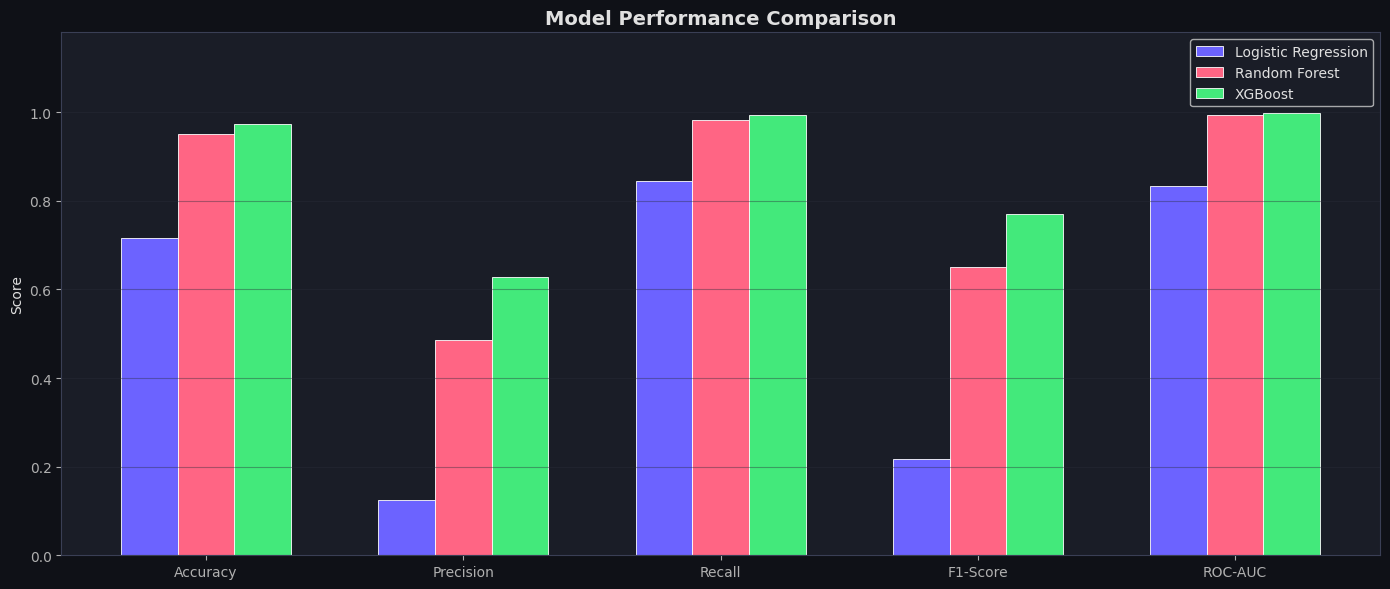

In [57]:
# ── 6.3 Metrics Bar Chart ────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
bar_w   = 0.22
offsets = np.linspace(-(len(models)-1)*bar_w/2,
                       (len(models)-1)*bar_w/2, len(models))

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, color) in enumerate(zip(models.keys(), PALETTE)):
    vals = [results[name][m] for m in metrics]
    ax.bar(x + offsets[i], vals, bar_w, label=name,
           color=color, edgecolor='white', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.18)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()


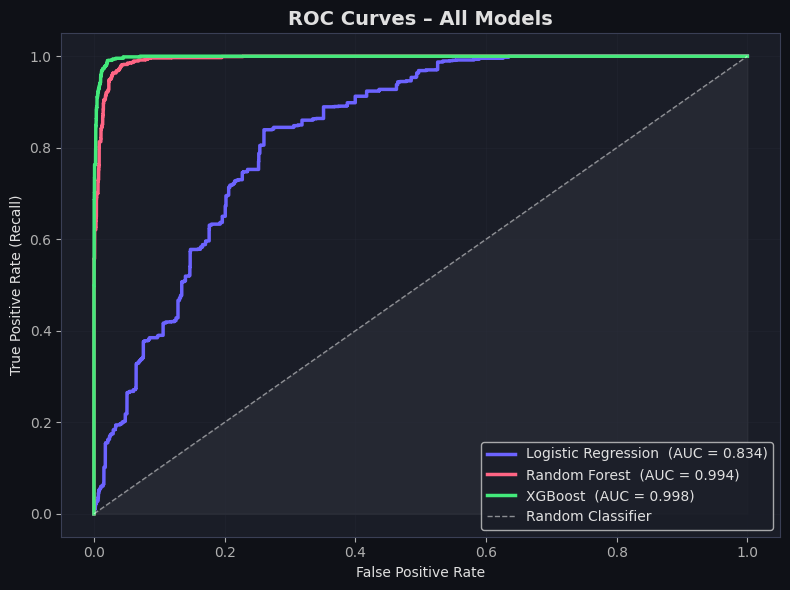

In [58]:
# ── 6.4 ROC Curves ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, color in zip(models.keys(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, y_probs[name])
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='white')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves – All Models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


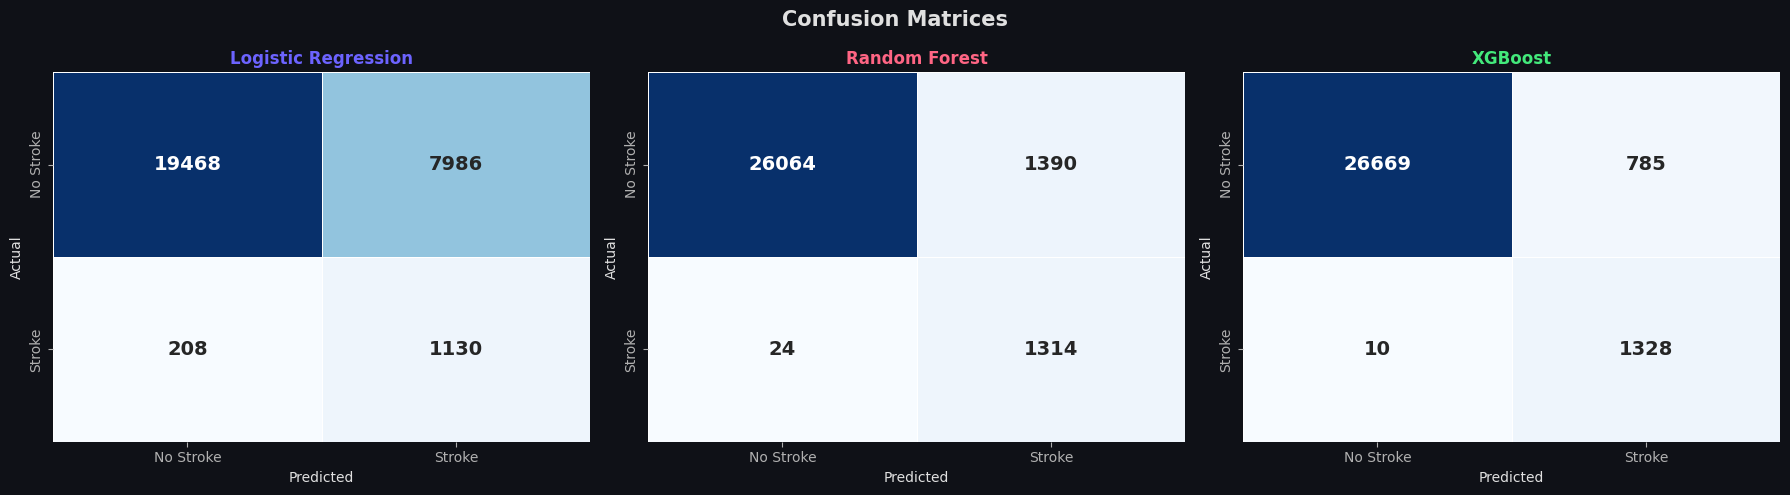

In [59]:
# ── 6.5 Confusion Matrices ───────────────────────────────────
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

for ax, (name, color) in zip(axes, zip(models.keys(), PALETTE)):
    cm = confusion_matrix(y_test, y_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'],
                linewidths=0.5, cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontweight='bold', fontsize=12, color=color)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()
plt.close()


## 🔍 Step 7 – Feature Importance
Understanding which features drive stroke prediction is crucial for:
- Clinical interpretability
- Academic submission
- Future feature selection


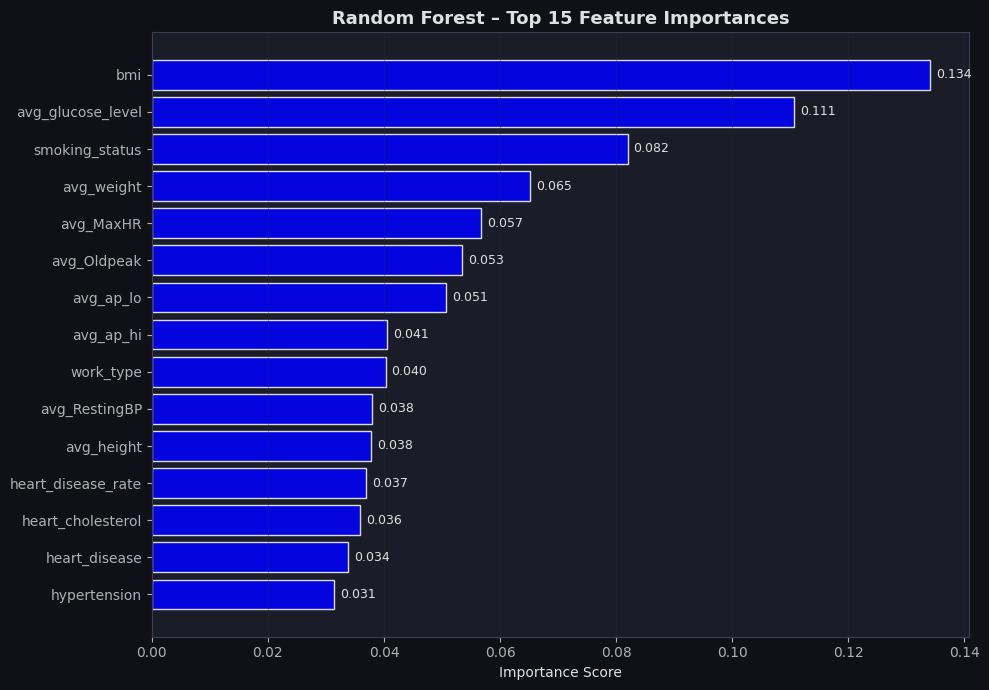

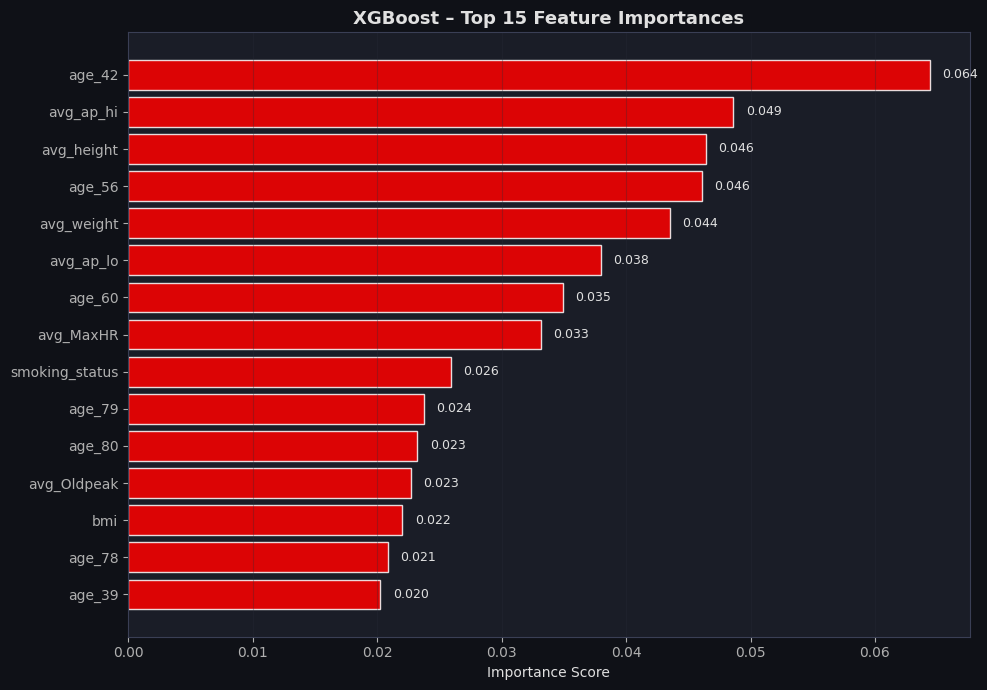

In [60]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# ── Use only tree models ────────────────────────────────────
tree_models = {n: m for n, m in trained.items() if n != 'Logistic Regression'}

# ✔️ IMPORTANT: must match training data
feature_names = list(X_train_encoded.columns)

for name, color in zip(tree_models.keys(), ['blue', 'red']):

    model = tree_models[name]

    importances = model.feature_importances_

    # safety check
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Mismatch! Model expects {len(importances)} features "
            f"but got {len(feature_names)} feature names"
        )

    indices = np.argsort(importances)[-15:]

    feats = [feature_names[i] for i in indices]
    vals  = importances[indices]

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.barh(feats, vals, color=color, alpha=0.85, edgecolor='white')

    for i, val in enumerate(vals):
        ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

    ax.set_title(f'{name} – Top 15 Feature Importances',
                 fontweight='bold', fontsize=13)

    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

plt.close('all')

In [61]:
# ── 7.2 Top Features Table ───────────────────────────────────
best_tree_name = max(tree_models.keys(), key=lambda n: results[n]['ROC-AUC'])
best_tree      = trained[best_tree_name]

imp_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': best_tree.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"🏆 Top 10 Features ({best_tree_name}):")
imp_df.head(10).style.background_gradient(subset=['Importance'], cmap='YlOrRd')


🏆 Top 10 Features (XGBoost):


,Feature,Importance
0,age_42,0.064388
1,avg_ap_hi,0.048610
2,avg_height,0.046417
3,age_56,0.046114
4,avg_weight,0.043535
5,avg_ap_lo,0.037991
6,age_60,0.034937
7,avg_MaxHR,0.033168
8,smoking_status,0.025910
9,age_79,0.023745


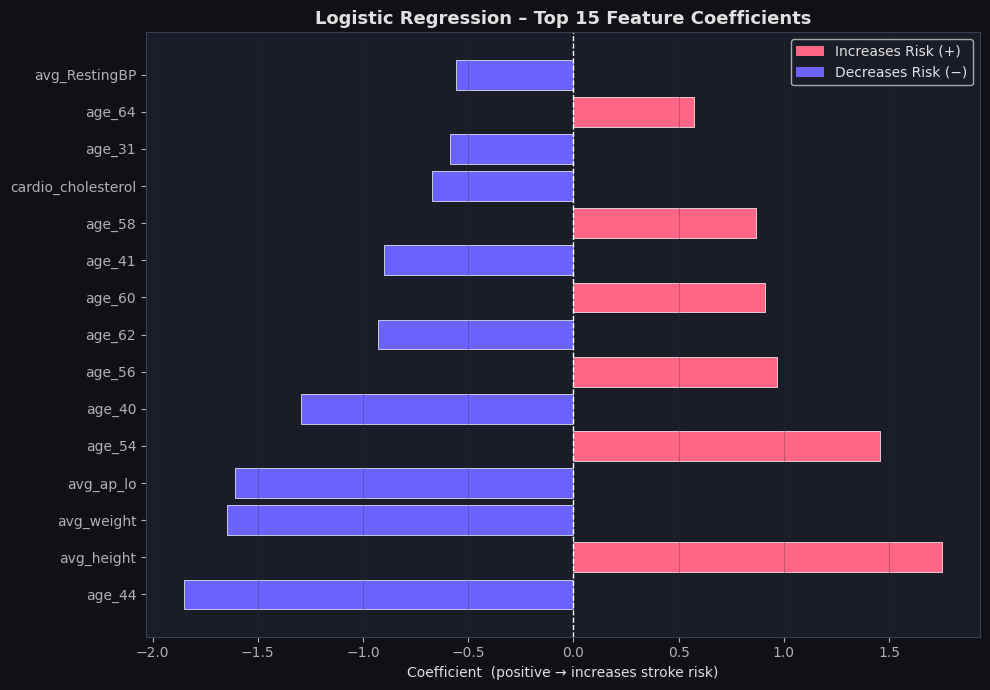

In [62]:
# ── 7.3 Logistic Regression Coefficients ─────────────────────
lr_model = trained['Logistic Regression']
coef_df  = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

top_coefs = coef_df.head(15)
colors    = [PALETTE[1] if c > 0 else PALETTE[0] for c in top_coefs['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_coefs['Feature'], top_coefs['Coefficient'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='white', lw=1, linestyle='--')
ax.set_title('Logistic Regression – Top 15 Feature Coefficients',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Coefficient  (positive → increases stroke risk)')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[1], label='Increases Risk (+)'),
    Patch(facecolor=PALETTE[0], label='Decreases Risk (−)')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()
plt.close()


## 🏆 Step 8 – Final Recommendation


In [63]:
# ── 8.1 Best Model by ROC-AUC ────────────────────────────────
results_df = pd.DataFrame(results).T

best_auc  = results_df['ROC-AUC'].idxmax()
best_rec  = results_df['Recall'].idxmax()
best_f1   = results_df['F1-Score'].idxmax()

print("=" * 58)
print("           FINAL MODEL RECOMMENDATION")
print("=" * 58)
print(f"  Best ROC-AUC   : {best_auc:<30} ({results[best_auc]['ROC-AUC']:.4f})")
print(f"  Best Recall    : {best_rec:<30} ({results[best_rec]['Recall']:.4f})")
print(f"  Best F1-Score  : {best_f1:<30} ({results[best_f1]['F1-Score']:.4f})")
print("=" * 58)
print()
print("📌 In healthcare stroke prediction:")
print("   Recall (sensitivity) is the MOST important metric.")
print("   Missing a true stroke (False Negative) is far more")
print("   dangerous than a false alarm (False Positive).")
print()
print(f"   ✅ Recommended Model: {best_rec}")
print("=" * 58)


           FINAL MODEL RECOMMENDATION
  Best ROC-AUC   : XGBoost                        (0.9981)
  Best Recall    : XGBoost                        (0.9925)
  Best F1-Score  : XGBoost                        (0.7696)

📌 In healthcare stroke prediction:
   Recall (sensitivity) is the MOST important metric.
   Missing a true stroke (False Negative) is far more
   dangerous than a false alarm (False Positive).

   ✅ Recommended Model: XGBoost


In [64]:
# ── 8.2 Final Summary Table ──────────────────────────────────
print("\n📊 Complete Model Summary:")
summary = results_df.round(4).copy()
summary['Best'] = ''
summary.loc[summary['ROC-AUC'].idxmax(), 'Best'] = '🏆 Best AUC'
summary.loc[summary['Recall'].idxmax(),  'Best'] = '🏥 Best Recall'
print(summary.to_string())



📊 Complete Model Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC           Best
Logistic Regression    0.7154     0.1240  0.8445    0.2162   0.8343               
Random Forest          0.9509     0.4859  0.9821    0.6502   0.9940               
XGBoost                0.9724     0.6285  0.9925    0.7696   0.9981  🏥 Best Recall


---
## 📌 Key Findings

1. **Age** and **BMI** are consistently the top features across all models  
2. **Hypertension** and **Heart Disease** significantly increase stroke risk  
3. **Avg Glucose Level** is a strong predictor (related to diabetes)  
4. **Smoking Status** has moderate influence  
5. The dataset is **imbalanced** (~5% stroke cases) → `class_weight='balanced'` was applied  
6. **Recall is prioritized** over accuracy in this healthcare context

---
*Project: Stroke Prediction | Data Mining AIE 323 | New Mansoura University*
